In [8]:
import numpy as np
import pandas as pd
import time
import FlowCal
from tqdm import tqdm

from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import f1_score, normalized_mutual_info_score, adjusted_rand_score, confusion_matrix
from sklearn.manifold import TSNE
from scipy.optimize import linear_sum_assignment
import seaborn as sns
import matplotlib.pyplot as plt


FILENAMES_NO_TRANSFORM = ["FlowRepository_FR-FCM-ZZPH_files/Levine_13dim_notransform.fcs",
                            "FlowRepository_FR-FCM-ZZPH_files/Levine_32dim_notransform.fcs",
                            "FlowRepository_FR-FCM-ZZPH_files/Mosmann_rare_notransform.fcs",
                            "FlowRepository_FR-FCM-ZZPH_files/Nilsson_rare_notransform.fcs",
                            "FlowRepository_FR-FCM-ZZPH_files/Samusik_01_notransform.fcs",
                            "FlowRepository_FR-FCM-ZZPH_files/Samusik_all_notransform.fcs"]
# Filenames
FILENAMES_TRANSFORM = [
    "FlowRepository_FR-FCM-ZZPH_files/Levine_13dim.fcs",
    "FlowRepository_FR-FCM-ZZPH_files/Levine_32dim.fcs",
    "FlowRepository_FR-FCM-ZZPH_files/Mosmann_rare.fcs",
    "FlowRepository_FR-FCM-ZZPH_files/Nilsson_rare.fcs",
    "FlowRepository_FR-FCM-ZZPH_files/Samusik_01.fcs",
    "FlowRepository_FR-FCM-ZZPH_files/Samusik_all.fcs"
]

# Test CSV File
TEST_CSV_FILE = "../Homework1/Levine_matrix.csv"

In [9]:
from tqdm import tqdm
import pandas as pd
import numpy as np
import FlowCal

summary_rows = []

for filename in tqdm(FILENAMES_TRANSFORM, desc="Datasets"):
    try:
        s = FlowCal.io.FCSData(filename)

        data_array = np.asarray(s)

        channel_names = s.channels

        df_labeled = pd.DataFrame(data_array, columns=channel_names)

        # Label information
        y_true_full = np.asarray(s[:, -1])
        n_total_cells = len(y_true_full)
        labeled_indices = ~np.isnan(y_true_full)
        n_labeled_cells = np.sum(labeled_indices)
        n_unlabeled_cells = np.sum(~labeled_indices)
        unique_labels = np.unique(y_true_full[labeled_indices])

        n_markers = len(channel_names) - 1
        X_full = data_array[:, :-1]

        valid_rows = ~np.isnan(X_full).any(axis=1)
        n_cells_after_nan_removal = np.sum(valid_rows)

        summary_rows.append({
            "Dataset Name": filename.split("/")[-1],
            "Number of Cells": n_total_cells,
            "Number of Labeled Cells": n_labeled_cells,
            "Number of Unlabeled Cells": n_unlabeled_cells,
            "Number of Unique Labels": len(unique_labels),
            "Number of Markers Measured": n_markers,
            "Number of Cells After Removing NaNs": n_cells_after_nan_removal
        })

        print(f"\n=== Dataset: {filename} ===")
        print(df_labeled.head())
        print(f"Number of unique labels: {len(unique_labels)}")
        print(f"Number of labeled cells: {n_labeled_cells}")
        print(f"Number of unlabeled cells: {n_unlabeled_cells}")
        print(f"Number of cells after removing NaNs: {n_cells_after_nan_removal}")
        print("="*60)

    except Exception as e:
        print(f"Error loading {filename}: {e}")
        continue


# summary_df = pd.DataFrame(summary_rows)
# summary_df.to_csv("fcs_summary_table.csv", index=False)



Datasets:  33%|███▎      | 2/6 [00:00<00:00, 11.87it/s]


=== Dataset: FlowRepository_FR-FCM-ZZPH_files/Levine_13dim.fcs ===
       CD45    CD45RA      CD19     CD11b       CD4       CD8      CD34  \
0  3.138041  1.618552  0.525611 -0.104680  0.811363  1.740672  0.531365   
1  3.486871  2.247755  0.309583  0.833397  1.550594  1.829030 -0.033018   
2  2.145520  0.796811 -0.116073  0.186249  0.529898  0.834876  0.734445   
3  4.321869  0.167016 -0.639139 -0.020982  1.814245 -0.094315  1.416341   
4  2.633997  0.714859 -0.173889 -0.042410  0.450911  1.587902  0.731608   

       CD20      CD33     CD123      CD38      CD90       CD3  label  
0 -0.153811  4.291140  2.615224  4.646570  1.849447  1.280036    1.0  
1  0.290684  4.672004  1.532877  4.253448  0.422374  0.066806    1.0  
2  1.590881  4.473148  0.443484  4.511387  0.124615 -2.066902    1.0  
3 -0.028213  4.295604  2.546383  5.004100  1.326005 -1.015953    1.0  
4  0.139234  4.115300  1.579856  5.065479  0.632904 -0.703904    1.0  
Number of unique labels: 24
Number of labeled cells: 81

Datasets:  67%|██████▋   | 4/6 [00:00<00:00, 14.07it/s]


=== Dataset: FlowRepository_FR-FCM-ZZPH_files/Mosmann_rare.fcs ===
           FSC-A     FSC-H         FSC-W         SSC-A    SSC-H         SSC-W  \
0   73212.664062   59145.0  81123.765625  44951.773438  40058.0  73542.343750   
1  116275.445312  100674.0  75692.117188  70193.070312  62834.0  73211.523438   
2  101123.101562   84974.0  77990.960938  45193.593750  40458.0  73206.968750   
3   78468.984375   66042.0  77867.773438  33581.953125  31118.0  70725.203125   
4   99652.500000   85059.0  76779.953125  42695.140625  39395.0  71025.992188   

      CXCR5     IL17A      TNFa  Live_Dead  ...      CD8a      CD14       IL5  \
0  0.849820  1.288759 -0.580224   1.047385  ...  0.302053  1.071113 -0.428378   
1  2.613073  5.205133  1.883536   2.692758  ...  6.896292  1.878968  8.054638   
2  0.895492  1.519545  1.723903   2.295498  ...  1.477839  1.179131 -0.290305   
3  1.432820  5.148185  2.053477   2.214397  ...  6.865357  1.968829  8.047993   
4  2.839495  0.480615  2.158275   1.8440

Datasets: 100%|██████████| 6/6 [00:00<00:00,  6.56it/s]


=== Dataset: FlowRepository_FR-FCM-ZZPH_files/Samusik_all.fcs ===
     Time  Cell_length         BC1         BC2         BC3        BC4  \
0   572.0         22.0  228.651947  121.627724  213.436554  12.419445   
1   857.0         32.0  178.314606  151.709244  201.901917   8.826335   
2  3076.0         27.0   59.644753   64.205711   85.310265   9.185763   
3  3082.0         18.0  144.572678  135.249725  149.918076   1.545513   
4  6156.0         24.0  242.359909  119.165802  242.052124   9.839778   

         BC5       BC6    Ter119    CD45.2  ...       IgM      CD44     MHCII  \
0   3.705995  1.023411 -0.108654  1.408508  ... -0.049208  3.360022  0.148652   
1  12.802864  2.262381 -0.136584  0.385353  ...  0.394026  4.005096  0.526787   
2   6.443371  3.799760 -0.059333  1.799704  ...  0.032650  4.522150  3.028800   
3   0.959142  0.348482 -0.110093  1.810717  ...  5.110682  0.572529  3.676500   
4   4.784545  2.360249 -0.149243  2.062939  ...  0.165025  4.489724  0.853335   

       

In [10]:
import pandas as pd
import glob

benchmark_folder = "benchmark_results_4/"


csv_files = glob.glob(benchmark_folder + "*.csv")
all_results = []

for file in csv_files:
    df = pd.read_csv(file)
    all_results.append(df)

# Combine all datasets into one big table
summary_table = pd.concat(all_results, ignore_index=True)

# summary_table.to_csv("combined_benchmark_results_4.csv", index=False)

print(summary_table.head())


                    dataset        method     runtime  memory_usage_MB  \
0  Levine_13dim_notransform        KMeans    2.203326        64.644531   
1  Levine_13dim_notransform        DBSCAN    3.552468        35.316406   
2  Levine_13dim_notransform  Hierarchical  975.629961         0.480469   
3  Levine_13dim_notransform   tSNE+KMeans  357.988904        44.394531   
4              Levine_32dim        KMeans    3.462054        89.031250   

        nmi       ari    purity  f1_score  \
0  0.615976  0.449213  0.619301  0.532648   
1  0.001101  0.000115  0.171260  0.000000   
2  0.673613  0.537918  0.639338  0.121341   
3  0.617846  0.383743  0.678153  0.533132   
4  0.004282  0.001613  0.253071  0.120484   

                                    confusion_matrix  
0  [[  584   144     4     0   114     0     0   ...  
1  [[    0     0     0     0     0     0     0   ...  
2  [[    0     0     0     0     0     0     0   ...  
3  [[   0    0    0    0    0    0    0    0    0...  
4  [[  90

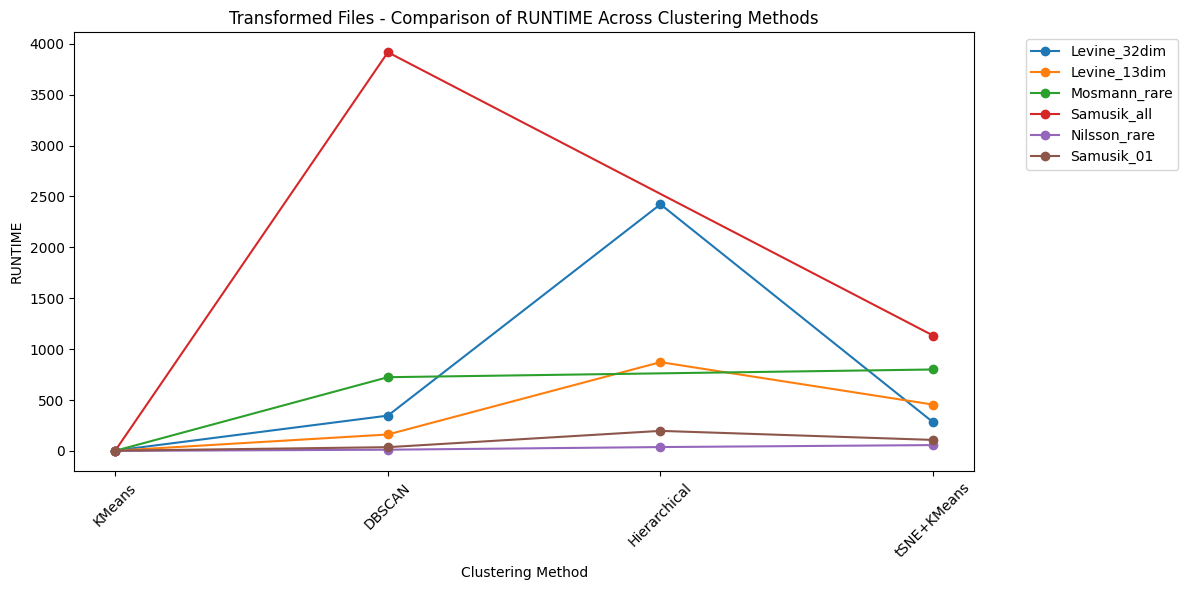

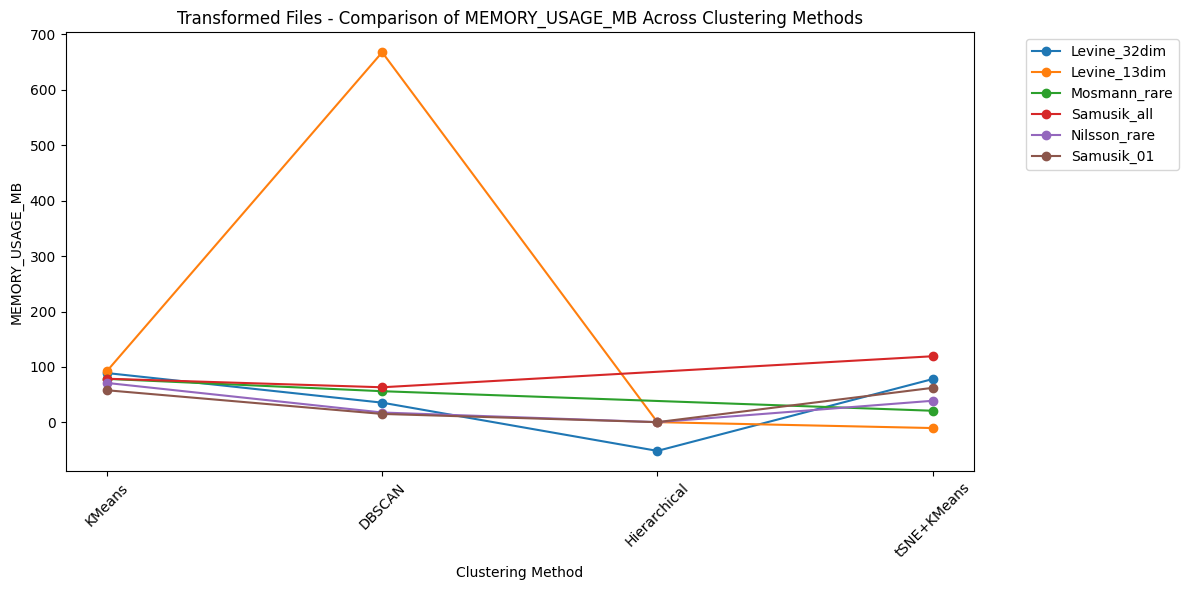

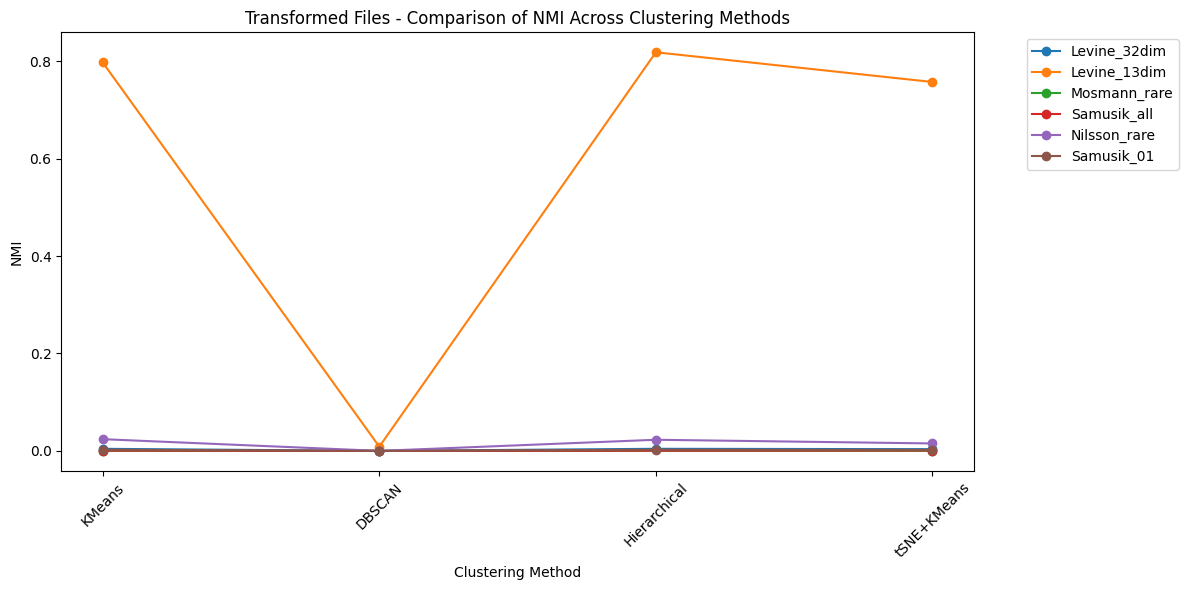

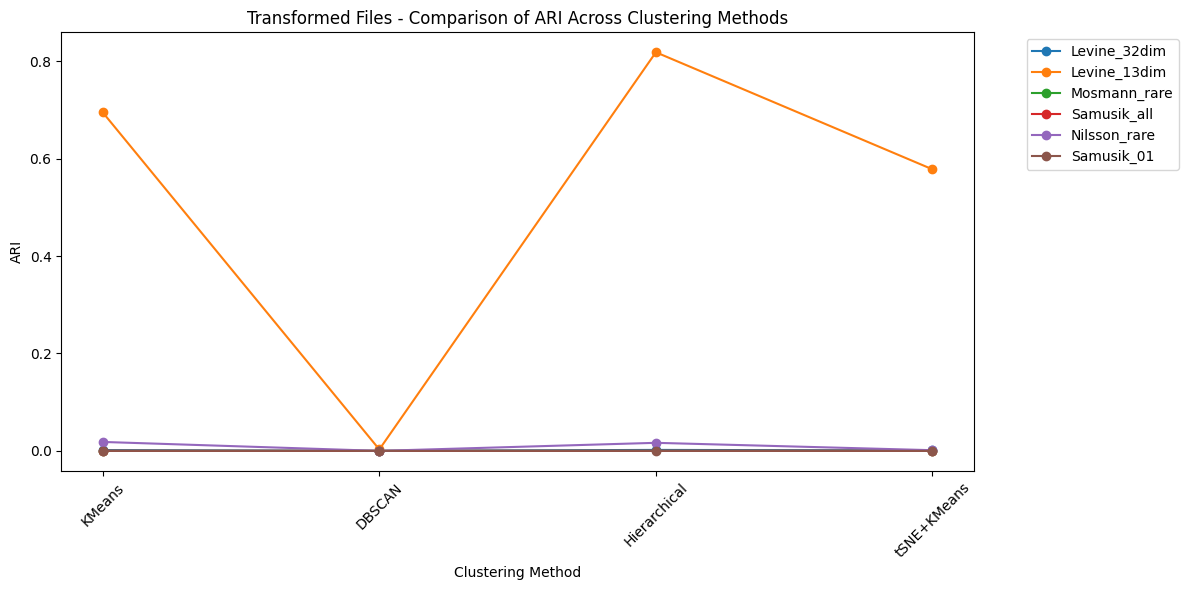

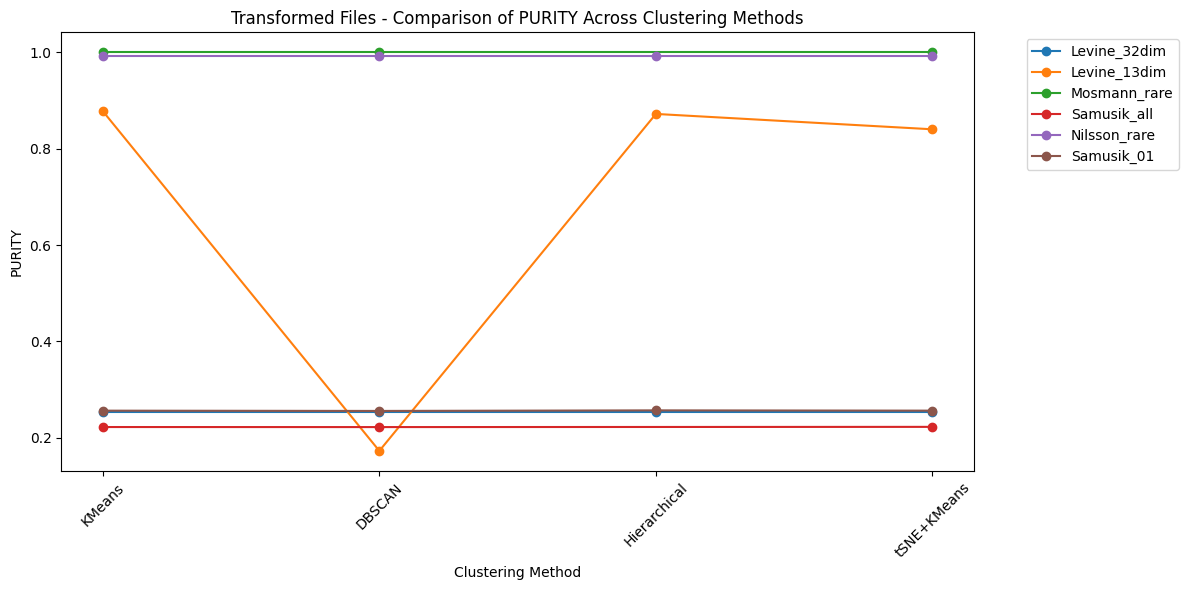

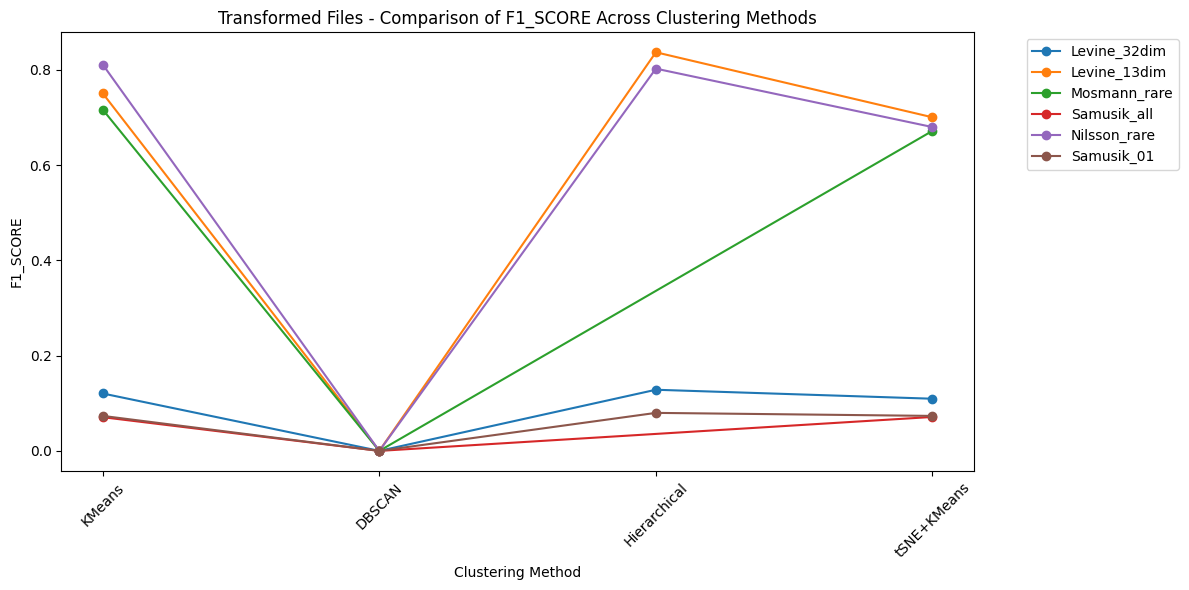

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

metrics = ['runtime', 'memory_usage_MB', 'nmi', 'ari', 'purity', 'f1_score']

for metric in metrics:
    plt.figure(figsize=(12, 6))
    plt.title(f"Transformed Files - Comparison of {metric.upper()} Across Clustering Methods")

    transformed_datasets = [d for d in summary_table['dataset'].unique() if "notransform" not in d]

    for dataset in transformed_datasets:
        df_subset = summary_table[summary_table['dataset'] == dataset]
        plt.plot(df_subset['method'], df_subset[metric], marker='o', label=dataset)

    plt.xlabel("Clustering Method")
    plt.ylabel(metric.upper())
    plt.xticks(rotation=45)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

    # plt.figure(figsize=(12, 6))
    # plt.title(f"Not-Transformed Files - Comparison of {metric.upper()} Across Clustering Methods")

    # notransformed_datasets = [d for d in summary_table['dataset'].unique() if "notransform" in d]

    # for dataset in notransformed_datasets:
    #     df_subset = summary_table[summary_table['dataset'] == dataset]
    #     plt.plot(df_subset['method'], df_subset[metric], marker='o', label=dataset)

    # plt.xlabel("Clustering Method")
    # plt.ylabel(metric.upper())
    # plt.xticks(rotation=45)
    # plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    # plt.tight_layout()
    # plt.show()


In [12]:
ranking = summary_table.groupby('method').agg({
    'nmi': 'mean',
    'ari': 'mean',
    'purity': 'mean',
    'f1_score': 'mean',
    'runtime': 'mean'
}).reset_index()

ranking = ranking.sort_values(by='nmi', ascending=False)

# ranking.to_csv("benchmark_algorithm_ranking.csv", index=False)
print(ranking)


         method       nmi       ari    purity  f1_score      runtime
1  Hierarchical  0.220530  0.199324  0.608904  0.411035   674.649715
2        KMeans  0.133788  0.107516  0.608308  0.431493     1.797388
3   tSNE+KMeans  0.128677  0.087764  0.610306  0.392956   539.862846
0        DBSCAN  0.000888  0.000278  0.503388  0.000009  1077.827935


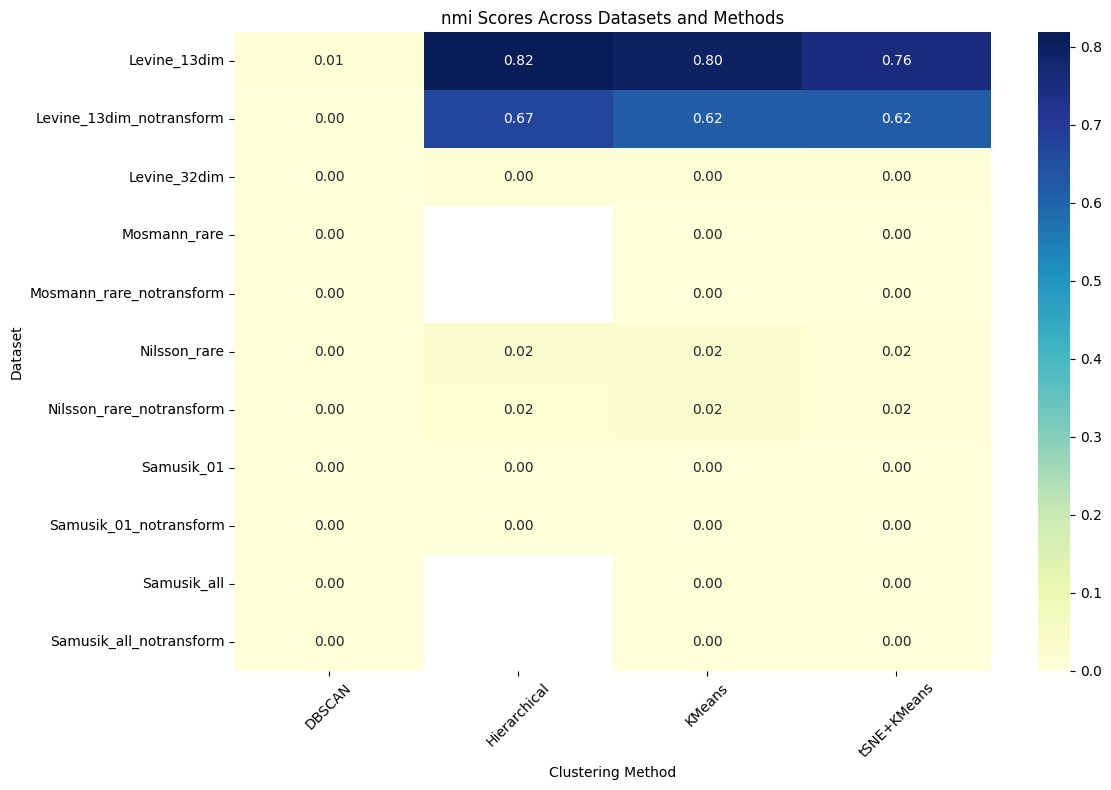

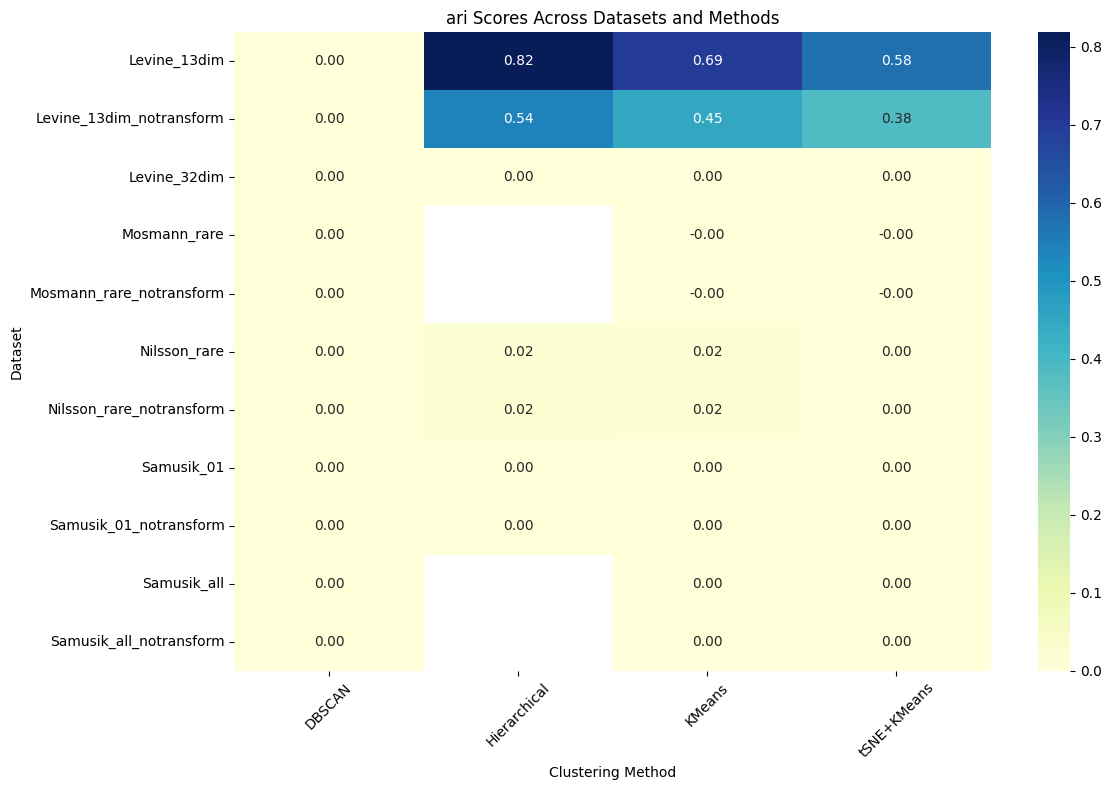

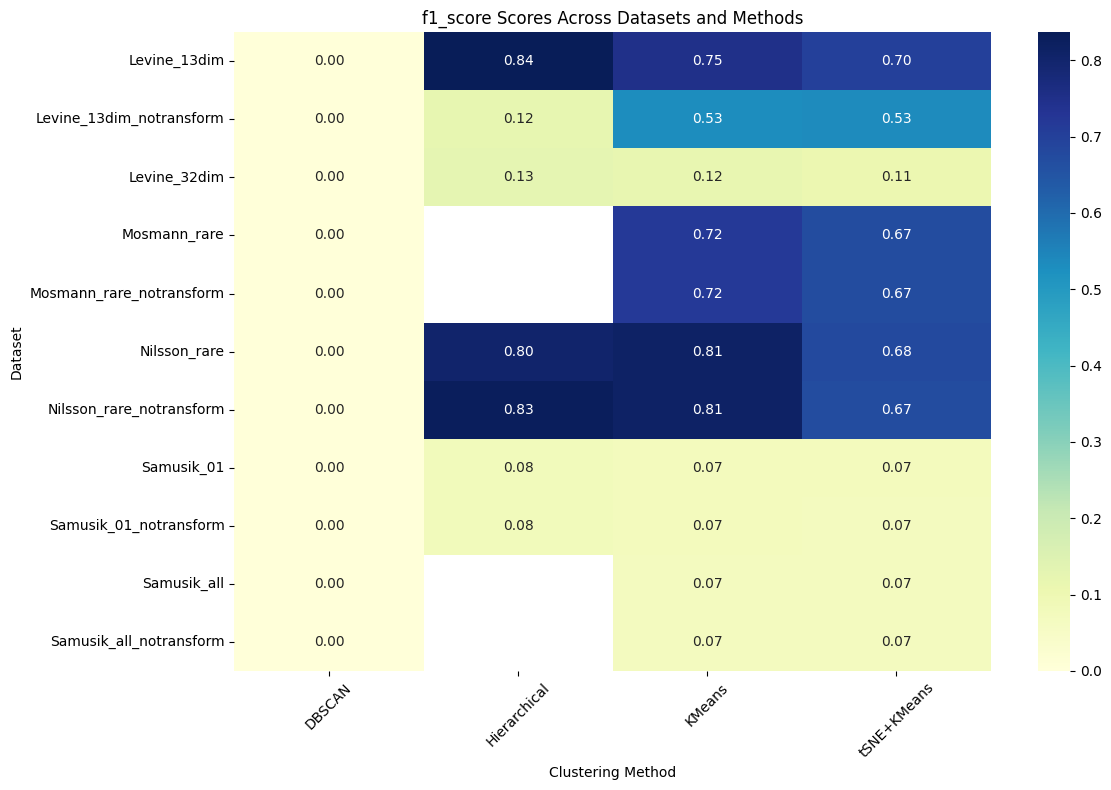

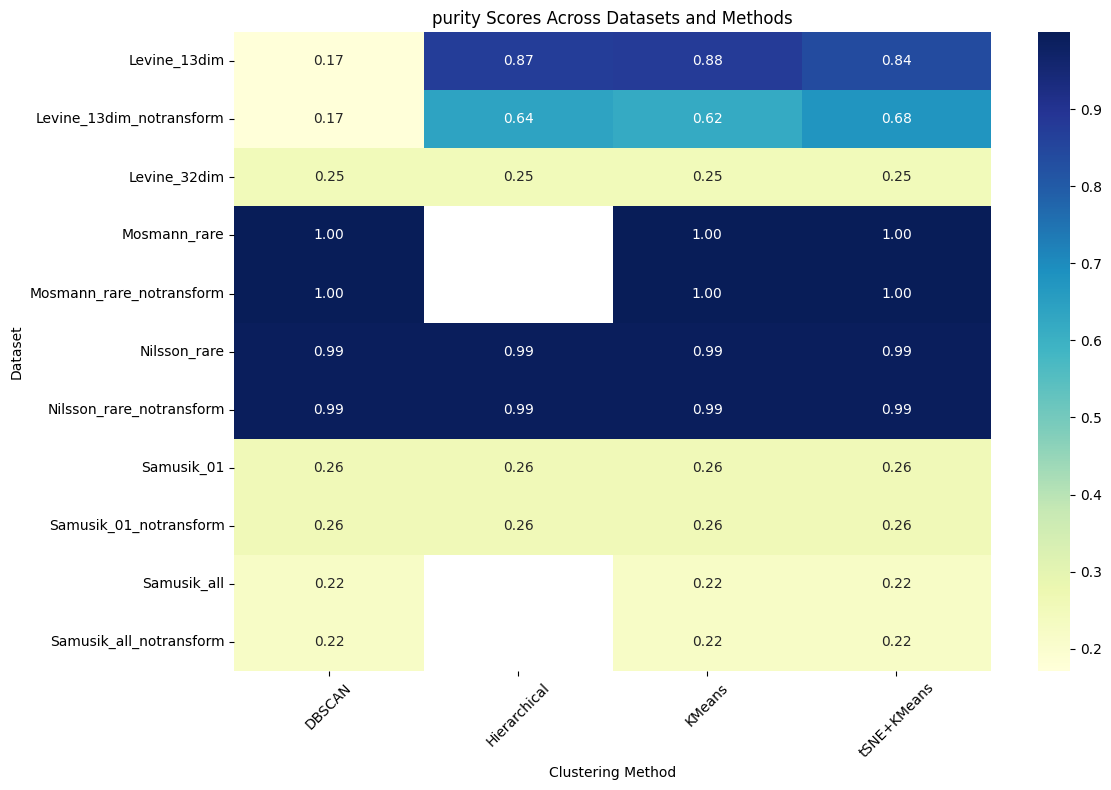

In [13]:
metrics = ['nmi', 'ari', 'f1_score', 'purity']
for metric in metrics:
    pivot_table = summary_table.pivot(index='dataset', columns='method', values=metric)

    plt.figure(figsize=(12, 8))
    sns.heatmap(pivot_table, annot=True, fmt=".2f", cmap="YlGnBu")
    plt.title(f"{metric} Scores Across Datasets and Methods")
    plt.xlabel("Clustering Method")
    plt.ylabel("Dataset")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


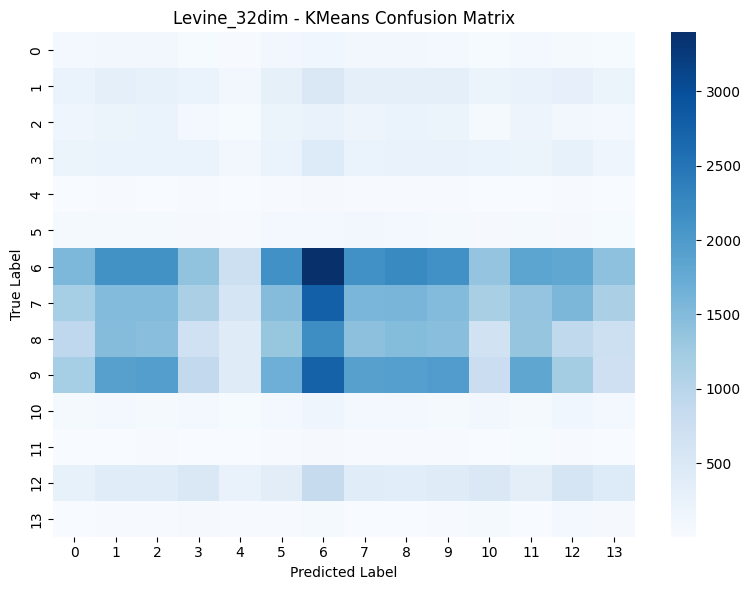

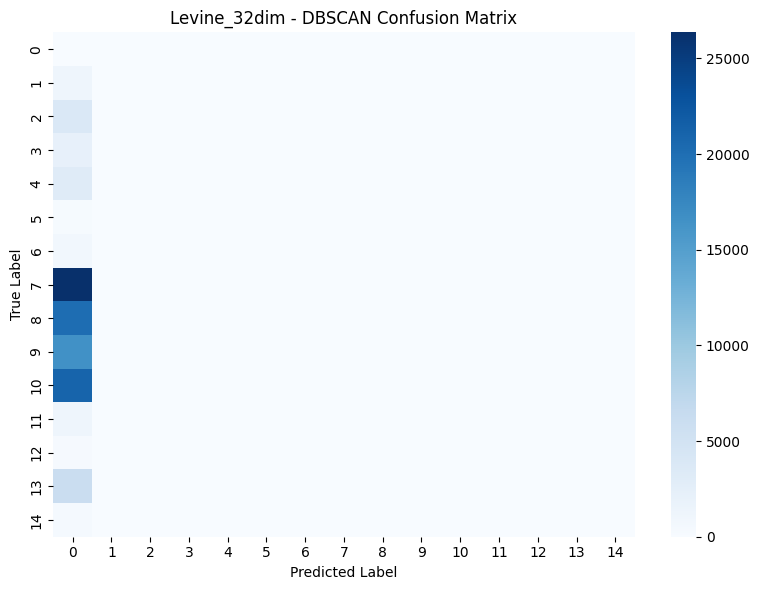

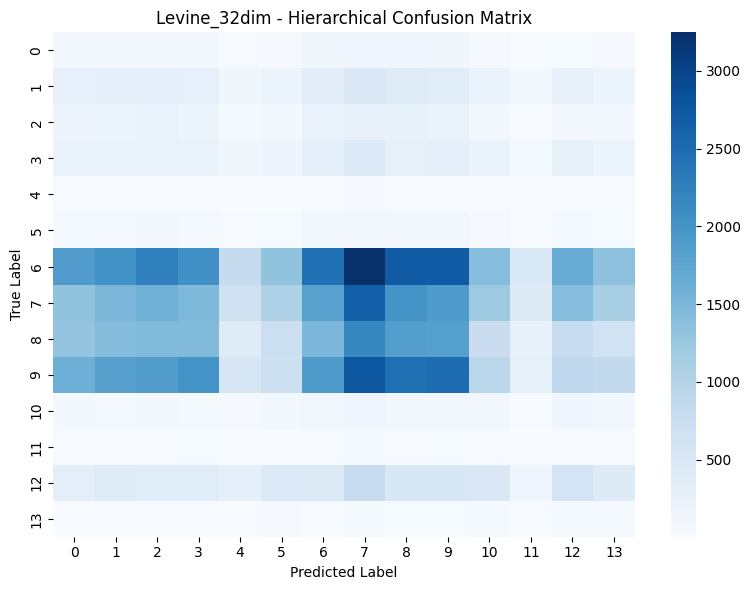

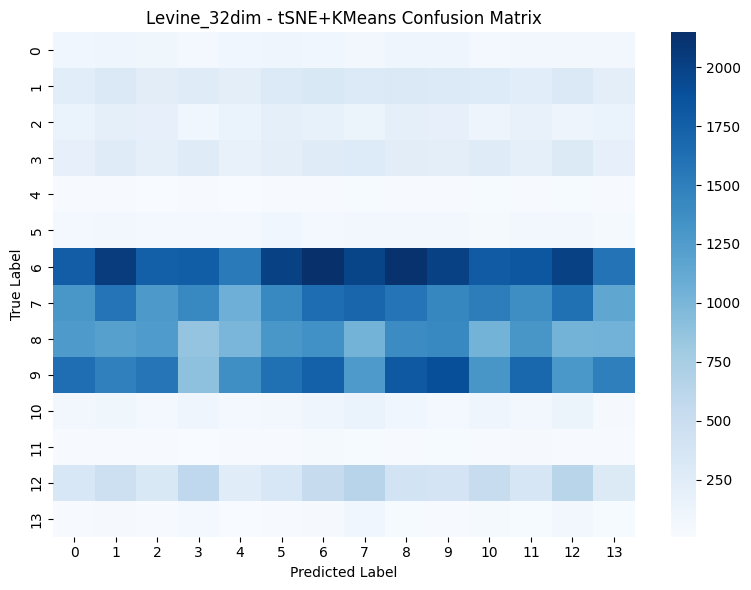

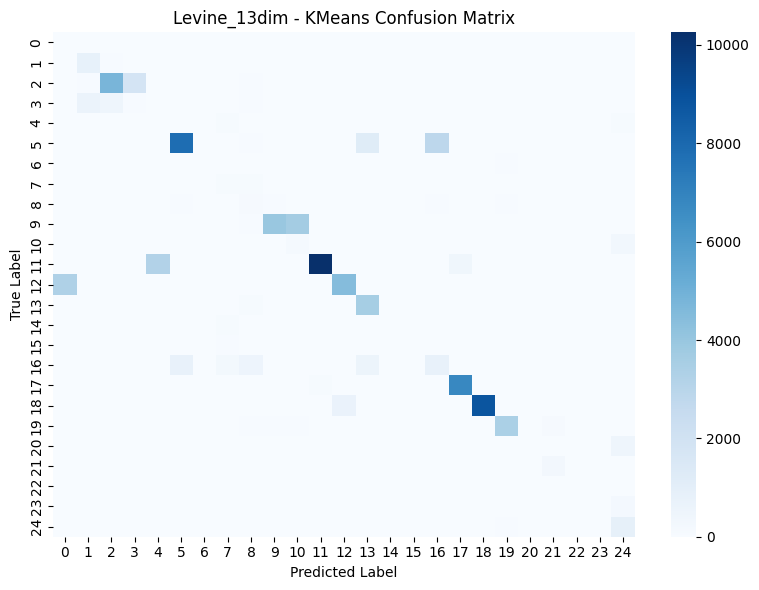

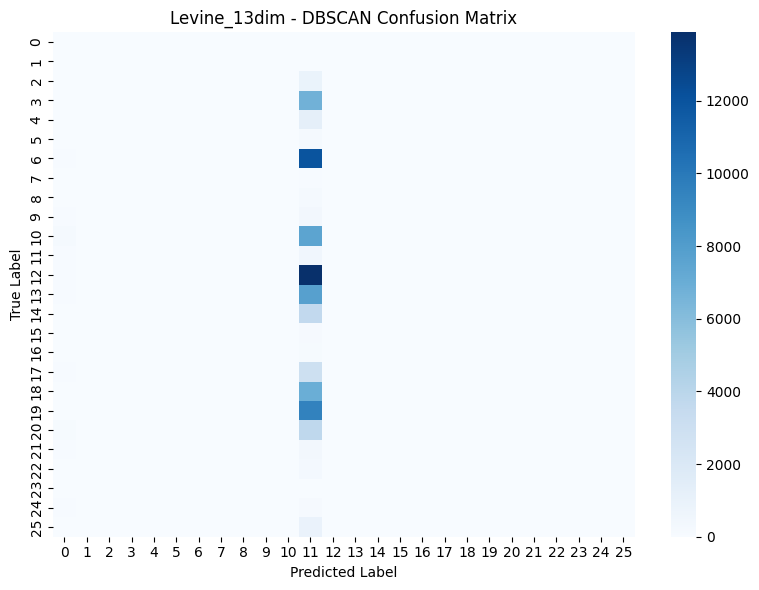

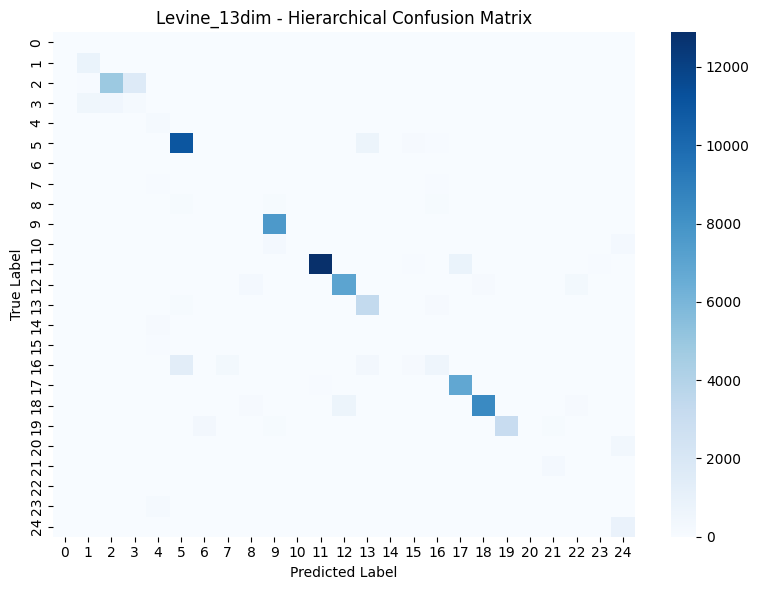

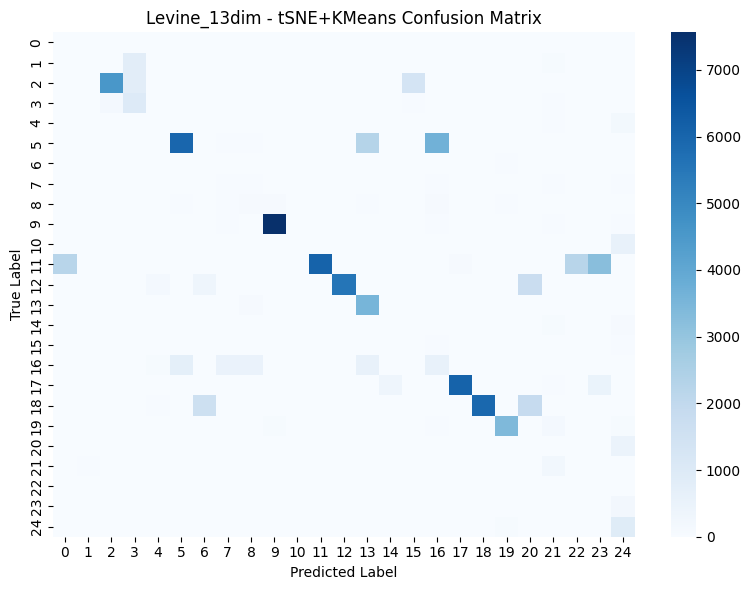

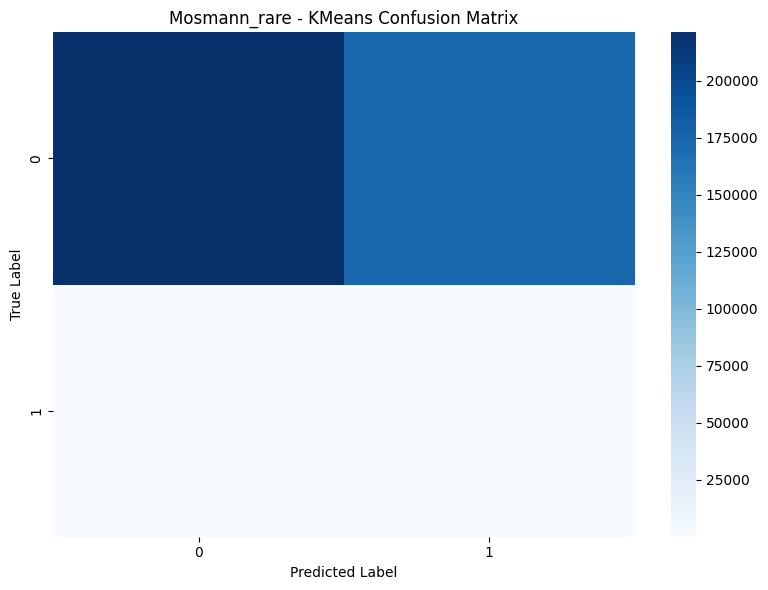

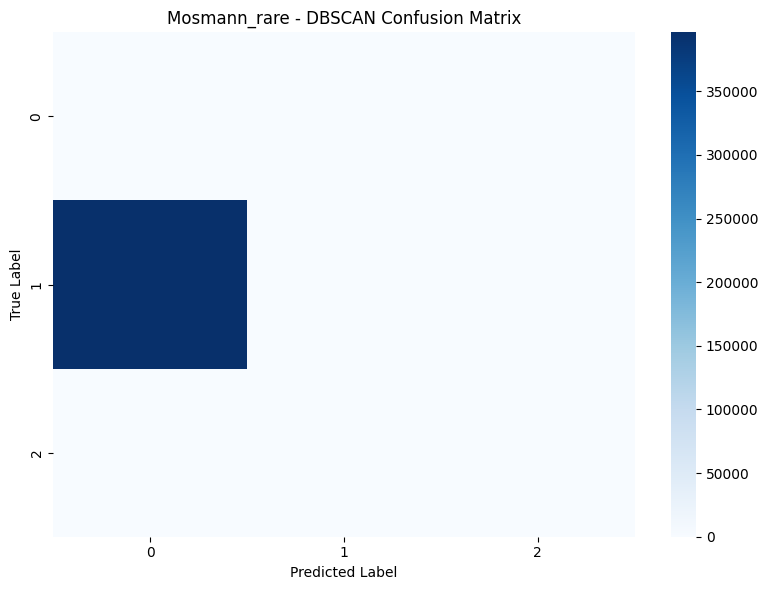

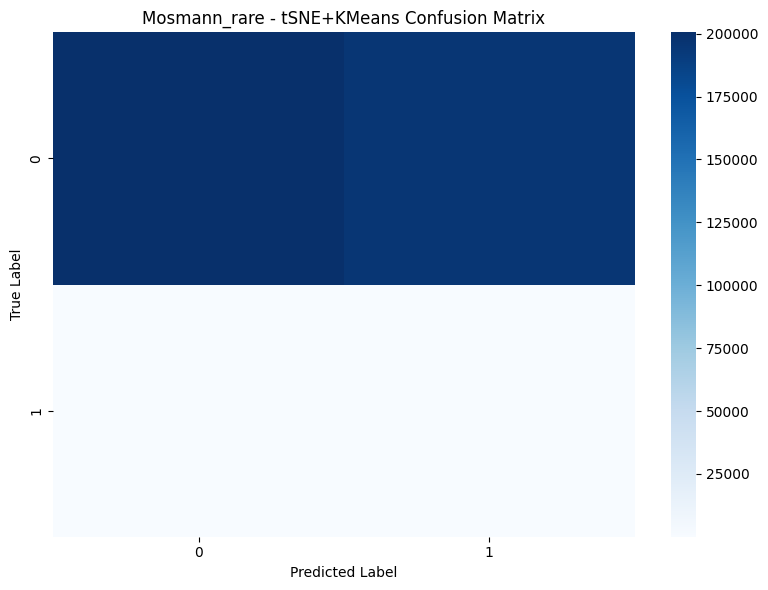

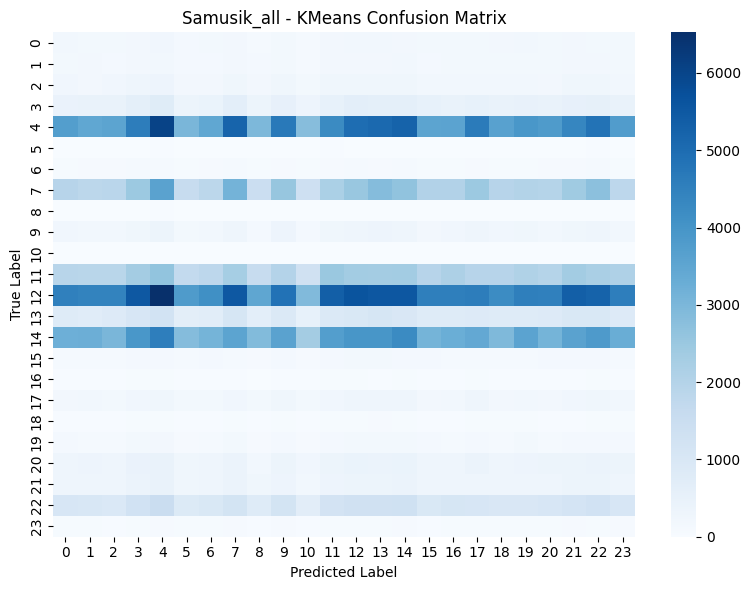

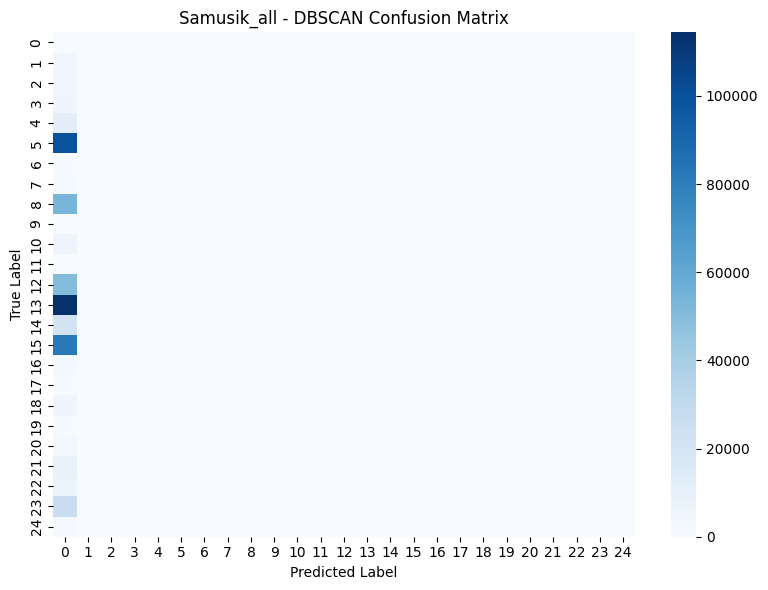

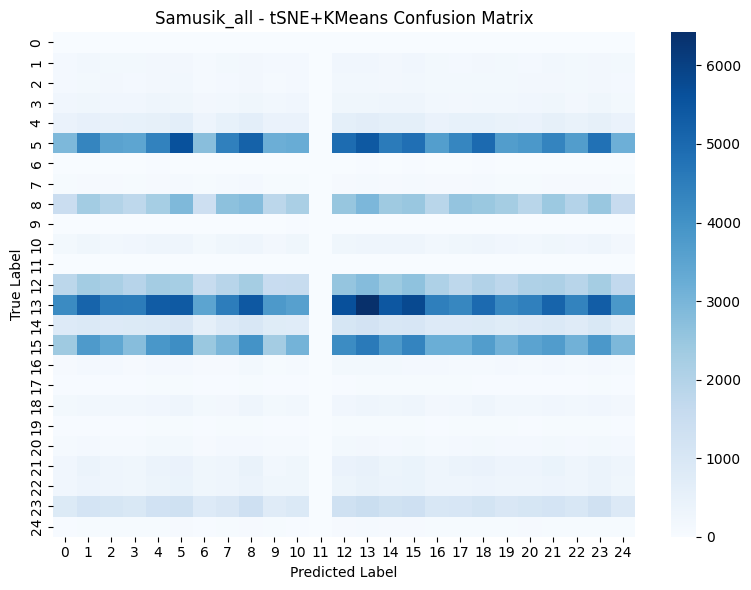

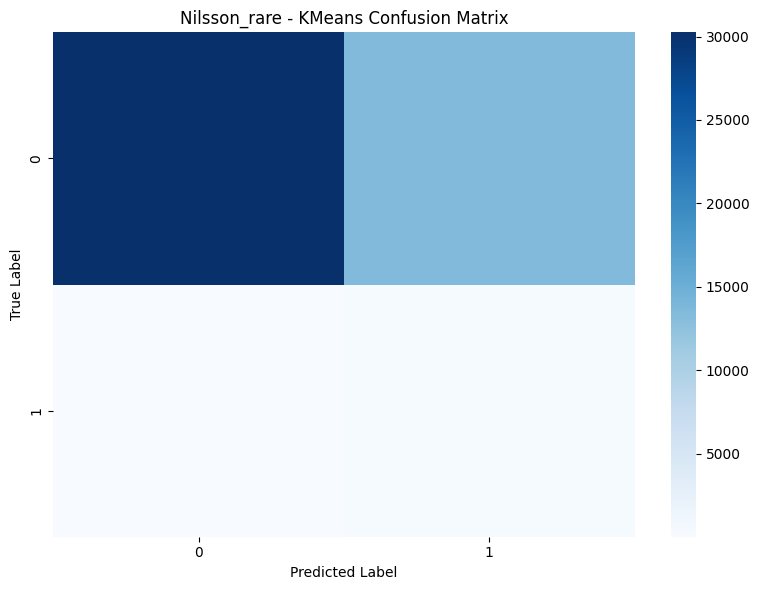

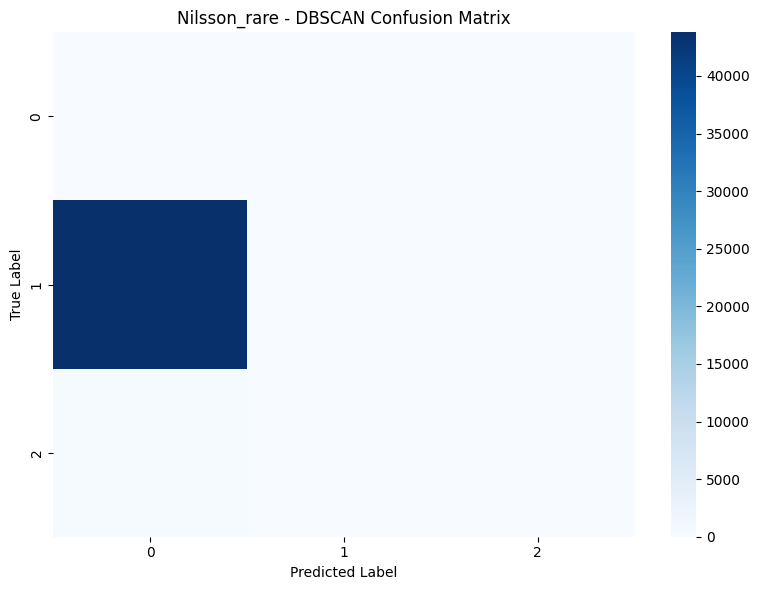

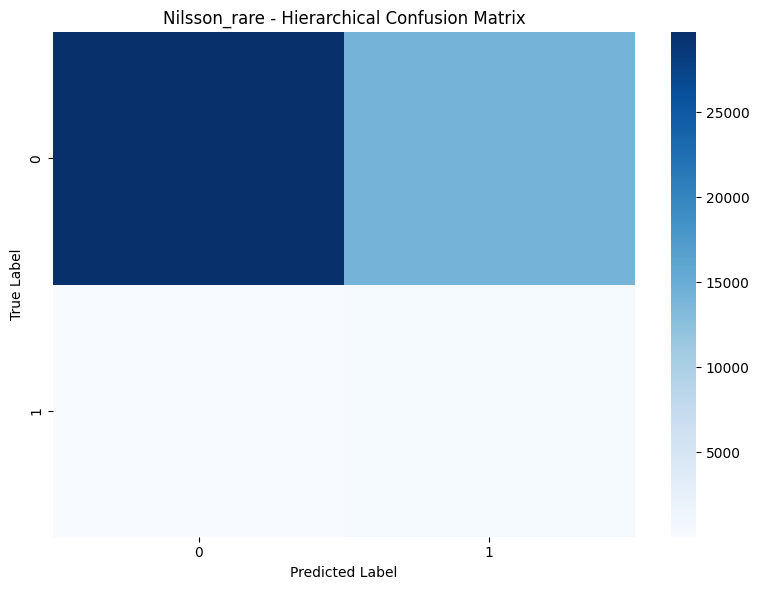

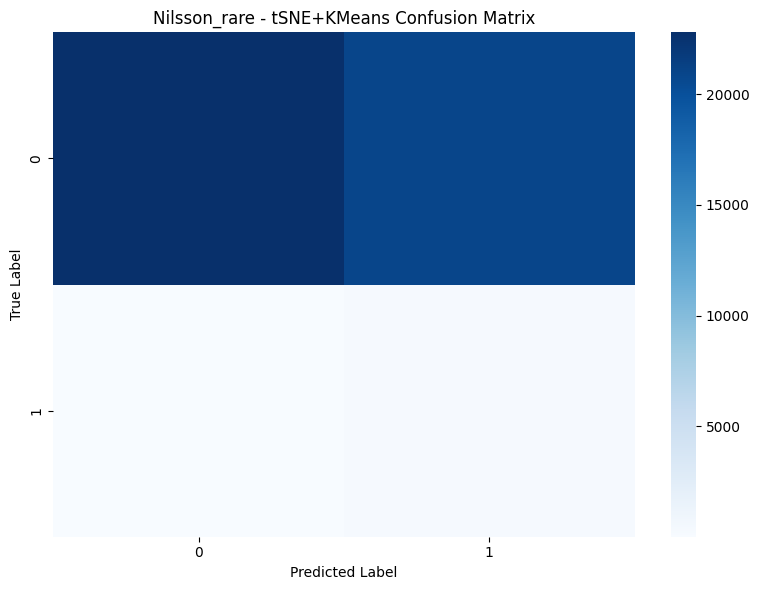

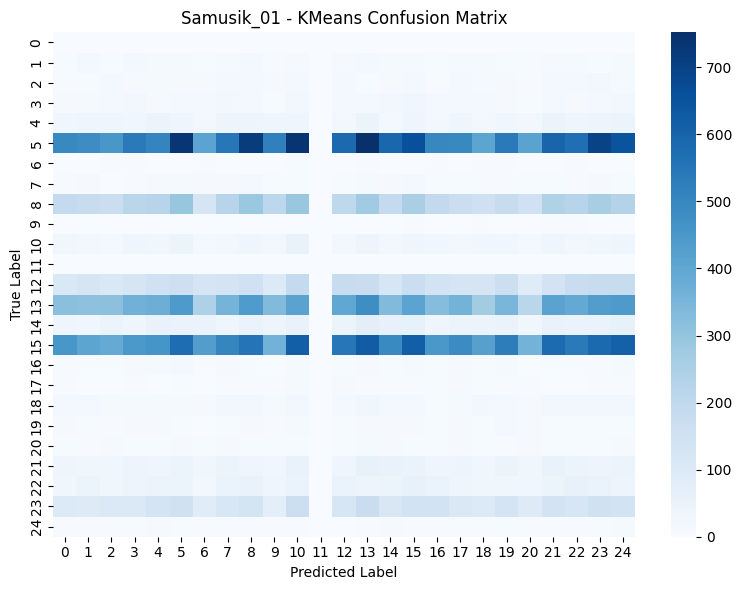

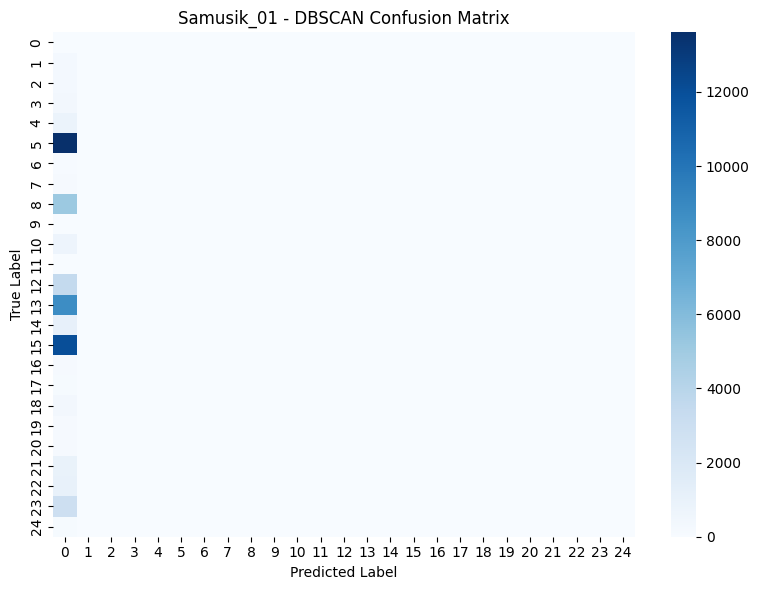

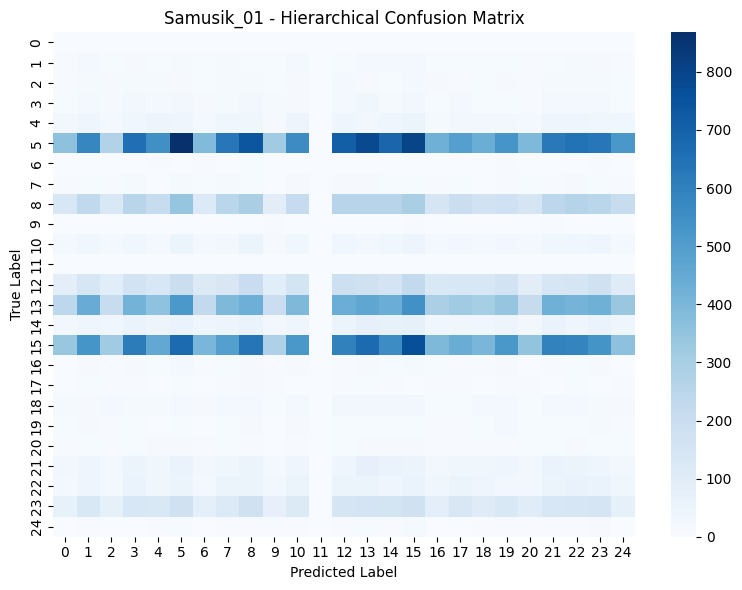

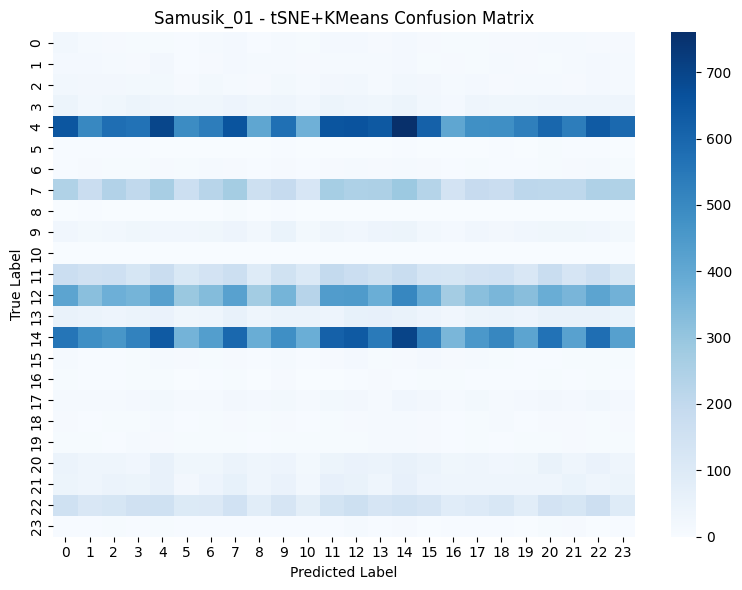

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# summary_table = pd.read_csv("combined_benchmark_results.csv")

transformed_datasets = [d for d in summary_table['dataset'].unique() if "notransform" not in d]

import pickle
import os

benchmark_folder = "benchmark_results_4/" 

for dataset_name in transformed_datasets:
    benchmark_file = os.path.join(benchmark_folder, dataset_name.replace(".fcs", "") + "_benchmark_full.pkl")
    if not os.path.exists(benchmark_file):
        print(f"Warning: Missing file {benchmark_file}")
        continue

    with open(benchmark_file, "rb") as f:
        full_result = pickle.load(f)

    benchmark_results = full_result['benchmark_results']

    for method_name, metrics in benchmark_results.items():
        if metrics is None:
            continue
        conf_mat = metrics['confusion_matrix']
        
        plt.figure(figsize=(8, 6))
        sns.heatmap(conf_mat, annot=False, cmap='Blues', fmt='d')
        plt.title(f"{dataset_name} - {method_name} Confusion Matrix")
        plt.xlabel("Predicted Label")
        plt.ylabel("True Label")
        plt.tight_layout()
        plt.show()
